# SURT URL Deduplication Analysis

Examines whether SURT URLs are deduplicated within each crawl year across all 15 target domains.

**Definitions:**
- **True duplicate**: same `(surtkey, fetch_timestamp)` appearing more than once — indicates a load/insert bug or double-run.
- **Multi-capture**: same `surtkey` with different timestamps within a year — valid; the crawler visited the same URL more than once.
- **Unique SURT URL**: distinct `surtkey` values, regardless of how many times each was captured.

Sections:
1. True duplicates check — per domain per year
2. Unique SURTs vs total records — crawl redundancy
3. Most-captured URLs per domain
4. Cross-year SURT overlap — which URLs persist across crawl years

In [1]:
import sys
sys.path.insert(0, '..')

import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

from config import TARGET_DOMAINS, DATA_DIR, AVAILABLE_YEARS
from split_domains import domain_folder_name

sns.set_theme(style='whitegrid')

DOMAINS_DIR = Path('..') / DATA_DIR / 'domains'

def db_path(domain: str) -> Path:
    folder = domain_folder_name(domain, TARGET_DOMAINS)
    return DOMAINS_DIR / folder / 'cdxj.duckdb'

missing = [d for d in TARGET_DOMAINS if not db_path(d).exists()]
print(f'{len(TARGET_DOMAINS) - len(missing)}/{len(TARGET_DOMAINS)} domain DBs found')
if missing:
    print('Missing:', missing)

15/15 domain DBs found


## 1. True Duplicates Check

A true duplicate is a row with the same `(surtkey, fetch_timestamp)` appearing more than once.
These should not exist and would indicate a double-run or insert bug.

In [2]:
dup_rows = []
for domain in TARGET_DOMAINS:
    p = db_path(domain)
    if not p.exists():
        continue
    con = duckdb.connect(str(p), read_only=True)
    results = con.sql("""
        SELECT
            crawl_year,
            COUNT(*) AS total_rows,
            COUNT(DISTINCT surtkey || '|' || fetch_timestamp) AS unique_surt_ts,
            COUNT(*) - COUNT(DISTINCT surtkey || '|' || fetch_timestamp) AS true_duplicates,
            COUNT(DISTINCT surtkey) AS unique_surturls
        FROM eot_captures
        GROUP BY crawl_year
        ORDER BY crawl_year
    """).fetchall()
    con.close()
    for row in results:
        dup_rows.append({
            'domain': domain,
            'crawl_year': row[0],
            'total_rows': row[1],
            'unique_surt_ts': row[2],
            'true_duplicates': row[3],
            'unique_surturls': row[4],
        })

df_dup = pd.DataFrame(dup_rows)
df_dup['multi_capture'] = df_dup['total_rows'] - df_dup['unique_surturls']
df_dup['redundancy_pct'] = (100 * (1 - df_dup['unique_surturls'] / df_dup['total_rows'])).round(2)
df_dup

,domain,crawl_year,total_rows,unique_surt_ts,true_duplicates,unique_surturls,multi_capture,redundancy_pct
0,usda.gov,2004,2587862,2587698,164,2182713,405149,15.66
1,usda.gov,2008,2892921,2892915,6,1946726,946195,32.71
2,usda.gov,2012,1324043,1323181,862,1009506,314537,23.76
3,usda.gov,2016,4297461,4297431,30,2613983,1683478,39.17
4,usda.gov,2020,42899582,42896587,2995,40623368,2276214,5.31
...,...,...,...,...,...,...,...,...
84,va.gov,2008,990134,989886,248,764807,225327,22.76
85,va.gov,2012,716329,715939,390,610179,106150,14.82
86,va.gov,2016,4733212,4733201,11,2932866,1800346,38.04
87,va.gov,2020,1679809,1677710,2099,1173150,506659,30.16


In [3]:
# Summary: any true duplicates?
total_true_dups = df_dup['true_duplicates'].sum()
if total_true_dups == 0:
    print('No true duplicates found across any domain or year.')
else:
    print(f'WARNING: {total_true_dups:,} true duplicates found!')
    print(df_dup[df_dup['true_duplicates'] > 0][['domain','crawl_year','true_duplicates']])

      domain crawl_year  true_duplicates
0   usda.gov       2004              164
1   usda.gov       2008                6
2   usda.gov       2012              862
3   usda.gov       2016               30
4   usda.gov       2020             2995
..       ...        ...              ...
84    va.gov       2008              248
85    va.gov       2012              390
86    va.gov       2016               11
87    va.gov       2020             2099
88    va.gov       2024            14254

[74 rows x 3 columns]


## 2. Unique SURTs vs Total Records — Crawl Redundancy

`redundancy_pct` = share of records that are re-captures of a previously-seen URL within the same year.
High redundancy means the crawler visited the same URLs many times 

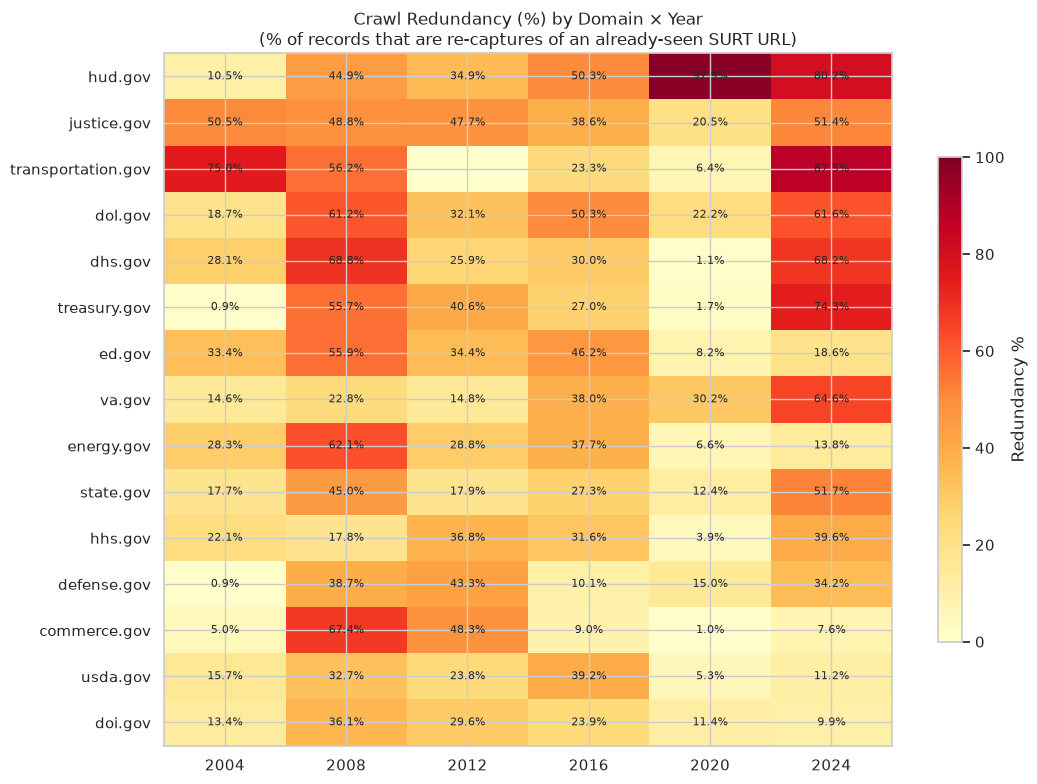

In [10]:
# Heatmap: redundancy % by domain × year
pivot_red = df_dup.pivot(index='domain', columns='crawl_year', values='redundancy_pct').fillna(0)
pivot_red = pivot_red.loc[pivot_red.mean(axis=1).sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(11, 8))
im = ax.imshow(pivot_red.values, aspect='auto', cmap='YlOrRd', vmin=0, vmax=100)
ax.set_xticks(range(len(pivot_red.columns)))
ax.set_xticklabels(pivot_red.columns)
ax.set_yticks(range(len(pivot_red.index)))
ax.set_yticklabels(pivot_red.index)
ax.set_title('Crawl Redundancy (%) by Domain × Year\n(% of records that are re-captures of an already-seen SURT URL)')

for i in range(len(pivot_red.index)):
    for j in range(len(pivot_red.columns)):
        val = pivot_red.values[i, j]
        if val > 0:
            ax.text(j, i, f'{val:.1f}%', ha='center', va='center', fontsize=8)

plt.colorbar(im, ax=ax, shrink=0.7, label='Redundancy %')
plt.tight_layout()
plt.show()

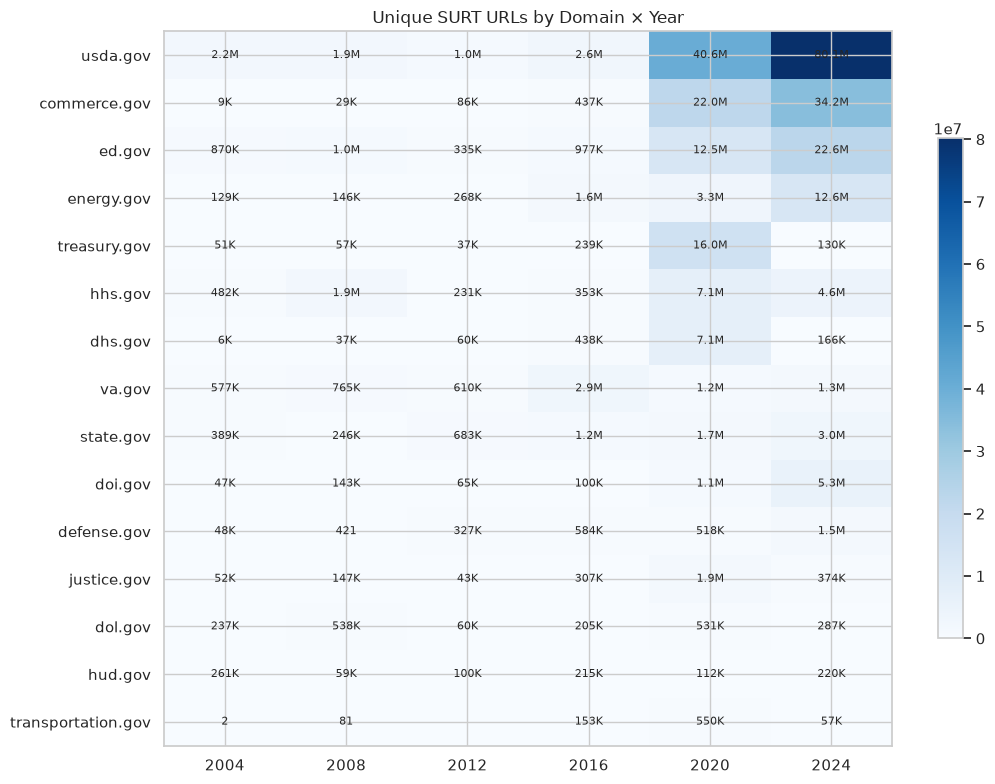

In [11]:
# Heatmap: unique SURT count by domain × year (absolute scale)
pivot_uniq = df_dup.pivot(index='domain', columns='crawl_year', values='unique_surturls').fillna(0).astype(int)
pivot_uniq = pivot_uniq.loc[pivot_uniq.sum(axis=1).sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(11, 8))
im = ax.imshow(pivot_uniq.values, aspect='auto', cmap='Blues')
ax.set_xticks(range(len(pivot_uniq.columns)))
ax.set_xticklabels(pivot_uniq.columns)
ax.set_yticks(range(len(pivot_uniq.index)))
ax.set_yticklabels(pivot_uniq.index)
ax.set_title('Unique SURT URLs by Domain × Year')

for i in range(len(pivot_uniq.index)):
    for j in range(len(pivot_uniq.columns)):
        val = pivot_uniq.values[i, j]
        label = f'{val/1e6:.1f}M' if val >= 1e6 else f'{val/1e3:.0f}K' if val >= 1000 else str(val) if val > 0 else ''
        ax.text(j, i, label, ha='center', va='center', fontsize=8)

plt.colorbar(im, ax=ax, shrink=0.7)
plt.tight_layout()
plt.show()

## 3. Most-Captured URLs per Domain

Which SURT URLs were fetched the most times within a single crawl year?

In [6]:
# Top 10 most-captured SURTs per domain (across all years)
top_captured = []
for domain in TARGET_DOMAINS:
    p = db_path(domain)
    if not p.exists():
        continue
    con = duckdb.connect(str(p), read_only=True)
    results = con.sql("""
        SELECT surtkey, crawl_year, COUNT(*) AS captures
        FROM eot_captures
        GROUP BY surtkey, crawl_year
        ORDER BY captures DESC
        LIMIT 10
    """).fetchall()
    con.close()
    for row in results:
        top_captured.append({'domain': domain, 'surtkey': row[0], 'crawl_year': row[1], 'captures': row[2]})

df_top = pd.DataFrame(top_captured)
df_top.sort_values(['domain', 'captures'], ascending=[True, False])

,domain,surtkey,crawl_year,captures
10,commerce.gov,dns:2014-2017.commerce.gov,2024,4154
11,commerce.gov,dns:2017-2021.commerce.gov,2024,4124
12,commerce.gov,dns:2001-2009.commerce.gov,2024,4089
13,commerce.gov,dns:2010-2014.commerce.gov,2024,4047
14,commerce.gov,dns:mbda.commerce.gov,2024,4029
...,...,...,...,...
145,va.gov,"gov,va,veteranshealthlibrary)/robots.txt",2024,3018
146,va.gov,dns:www.hsrd.research.va.gov,2024,2872
147,va.gov,"gov,va,benefits)/robots.txt",2024,2785
148,va.gov,dns:department.va.gov,2024,2735


In [7]:
# Overall top 20 most-captured SURTs across all domains
df_top.nlargest(20, 'captures')[['domain', 'crawl_year', 'surtkey', 'captures']]

,domain,crawl_year,surtkey,captures
70,hud.gov,2020,"gov,hud)/sites/documents/92547-a.pdf",420171
71,hud.gov,2020,"gov,hud)/sites/documents/doc_11183.html",391659
72,hud.gov,2020,"gov,hud)/sites/documents/14-14hsgn.pdf",388854
73,hud.gov,2020,"gov,hud)/sites/documents/45661x14hsgh.pdf",386111
74,hud.gov,2020,"gov,hud)/sites/documents/10-29pihnatch.xls",377533
75,hud.gov,2020,"gov,hud)/sites/documents/cinbustour-ss.jpg",374353
76,hud.gov,2020,"gov,hud)/sites/documents/45603tochsgh.pdf",372113
77,hud.gov,2020,"gov,hud)/sites/documents/attachment5.pdf",368032
78,hud.gov,2020,"gov,hud)/sites/documents/96-18ml.docx",362668
79,hud.gov,2020,"gov,hud)/sites/documents/27061-h.doc",362542


## 4. Cross-Year SURT Overlap

Which URLs appear in multiple crawl years? High overlap = stable, long-lived pages.
Low overlap = high turnover in a domain's URL space between crawls.

In [8]:
overlap_rows = []
for domain in TARGET_DOMAINS:
    p = db_path(domain)
    if not p.exists():
        continue
    con = duckdb.connect(str(p), read_only=True)

    # Count of distinct SURTs appearing in exactly N crawl years
    results = con.sql("""
        WITH surt_years AS (
            SELECT surtkey, COUNT(DISTINCT crawl_year) AS year_count
            FROM eot_captures
            GROUP BY surtkey
        )
        SELECT year_count, COUNT(*) AS surt_count
        FROM surt_years
        GROUP BY year_count
        ORDER BY year_count
    """).fetchall()
    con.close()
    for year_count, surt_count in results:
        overlap_rows.append({'domain': domain, 'years_present': year_count, 'unique_surts': surt_count})

df_overlap = pd.DataFrame(overlap_rows)

# Pivot for display
pivot_overlap = df_overlap.pivot(index='domain', columns='years_present', values='unique_surts').fillna(0).astype(int)
pivot_overlap.columns = [f'{c} year(s)' for c in pivot_overlap.columns]
pivot_overlap['total_unique_surts'] = pivot_overlap.sum(axis=1)
pivot_overlap.sort_values('total_unique_surts', ascending=False)

,1 year(s),2 year(s),3 year(s),4 year(s),5 year(s),6 year(s),total_unique_surts
domain,,,,,,,
usda.gov,122799138,2560989,143348,24552,7662,1137,125536826
commerce.gov,54415474,1102062,46049,297,22,6,55563910
ed.gov,36347866,626961,181247,33776,7840,1577,37199267
energy.gov,17456115,218837,53874,6741,421,114,17736102
treasury.gov,16229732,107113,15068,2666,419,49,16355047
hhs.gov,13977827,258617,47594,11490,1905,315,14297748
dhs.gov,7638541,49054,10540,1309,189,14,7699647
va.gov,6297506,379084,73527,22716,4810,551,6778194
doi.gov,6679254,41196,6124,331,87,19,6727011


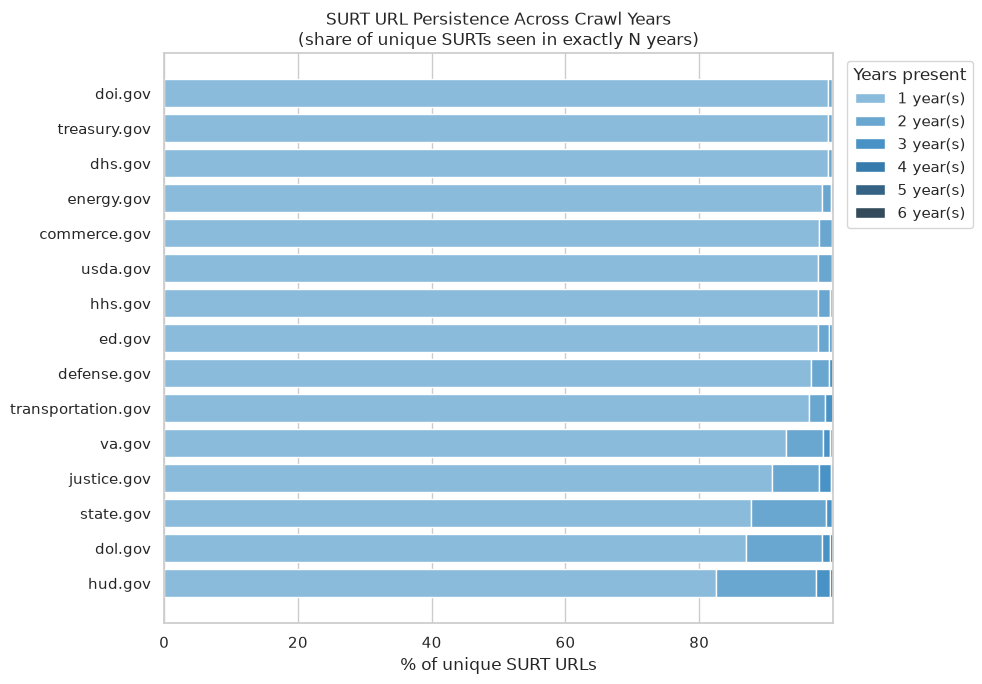

In [9]:
# Stacked bar: for each domain, share of SURTs seen in 1 / 2 / 3+ years
df_pct_overlap = pivot_overlap.drop(columns='total_unique_surts').div(pivot_overlap['total_unique_surts'], axis=0) * 100
df_pct_overlap = df_pct_overlap.sort_values('1 year(s)', ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
colors = sns.color_palette('Blues_d', len(df_pct_overlap.columns))
bottom = pd.Series([0.0] * len(df_pct_overlap), index=df_pct_overlap.index)
for col, color in zip(df_pct_overlap.columns, colors):
    vals = df_pct_overlap[col].fillna(0)
    ax.barh(df_pct_overlap.index, vals, left=bottom, label=col, color=color)
    bottom += vals

ax.set_xlabel('% of unique SURT URLs')
ax.set_title('SURT URL Persistence Across Crawl Years\n(share of unique SURTs seen in exactly N years)')
ax.axvline(100, color='grey', linewidth=0.5)
ax.legend(title='Years present', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()